# Kratos MCP Server — cantilever beam walkthrough

This notebook drives the **real** `kratos-mcp` server exactly the way an AI
assistant does: it spawns it as a subprocess over stdio using the official
[`mcp`](https://pypi.org/project/mcp/) Python client SDK, then calls tools
one by one. Every output in this notebook comes from a live run against a
compiled Kratos 10.4 build — there is no mocking anywhere.

It works through the same 1 m × 0.2 m steel cantilever plate as
[`docs/tutorials/cantilever-beam.md`](../docs/tutorials/cantilever-beam.md)
— fixed on the left edge, a 1 MN/m downward line load on the right — and
then goes further, touching most of the server's surface:

1. Connect to the server and discover its tools/resources/prompts
2. Introspect the installation (applications, elements, conditions,
   constitutive laws, variables, solvers, processes)
3. Read a worked-example resource and a guided prompt
4. Generate a structured mesh and inspect/validate it
5. Scaffold a case from a template and add a boundary condition
6. Run the simulation as a background job and watch it finish
7. Post-process the VTK results and sanity-check them against beam theory
8. Render the deformed shape inline (`results_render`)
9. Bonus: a short dynamic run, live job-progress polling, an animated GIF
   (`results_animate`), and cancelling a job in flight
10. Bonus: the low-level scaffolding tools (`create_project_parameters`,
    `create_materials`) as an alternative to `create_project`

## Requirements

- A working Kratos installation reachable the same way the server resolves
  it (`KRATOS_ROOT` build tree, or pip-installed) — see
  [docs/guide/installation.md](../docs/guide/installation.md).
- The `viz` extra for the rendering steps: `uv sync --extra viz`.
- A Jupyter kernel with `mcp`, `meshio`, `numpy` and (for the visual cells)
  `pyvista`/`imageio` importable — the project's own `.venv` has all of
  these once you run `uv sync --extra viz --group dev` (the `dev` group adds
  `ipykernel` so this notebook can run against it).

This is a live client session: cells depend on the ones above them
(the `session` object, `workdir`, `job_id`, ... are reused), so run the
notebook top to bottom rather than out of order.

In [1]:
import asyncio
import base64
import json
import shutil
import sys
import tempfile
from contextlib import AsyncExitStack
from pathlib import Path

from IPython.display import Image as IPImage, Markdown, display

from mcp import ClientSession, StdioServerParameters
from mcp.client.stdio import stdio_client


def _preview(value, limit=4000):
    text = value if isinstance(value, str) else json.dumps(value, indent=2, default=str)
    if len(text) > limit:
        text = text[: limit] + f"\n... [truncated, {len(text)} chars total]"
    print(text)


async def call(tool_name, **kwargs):
    # Call an MCP tool, print its JSON result, display any inline images,
    # and return the parsed value for use in later cells.
    result = await session.call_tool(tool_name, kwargs)
    value = None
    for block in result.content:
        if block.type == "text":
            try:
                value = json.loads(block.text)
            except json.JSONDecodeError:
                value = block.text
        elif block.type == "image":
            display(IPImage(data=base64.b64decode(block.data), format=block.mimeType.split("/")[-1]))
    _preview(value)
    return value


async def read_resource(uri):
    result = await session.read_resource(uri)
    return result.contents[0].text


async def get_prompt(name, **kwargs):
    result = await session.get_prompt(name, kwargs)
    return result.messages[0].content.text

## 1. Connect to the server and discover what it offers

The server and its stdio pipes are managed by anyio context managers whose cancel scopes are tied to the asyncio Task that opened them. Every Jupyter cell runs its top-level `await` in a *new* Task, so entering here and closing in the cleanup cell at the end (a different Task) would fail. The fix: run the whole connect → ... → disconnect lifecycle inside one persistent background task that outlives any single cell, and only *signal* it (via an `asyncio.Event`) from wherever we want; `session` itself can still be awaited from any cell just fine.

In [2]:
session = None
_stop_event = asyncio.Event()
_ready_event = asyncio.Event()


async def _server_lifecycle():
    global session
    async with AsyncExitStack() as stack:
        params = StdioServerParameters(command=sys.executable, args=["-m", "kratos_mcp.server"])
        read, write = await stack.enter_async_context(stdio_client(params))
        session = await stack.enter_async_context(ClientSession(read, write))
        await session.initialize()
        _ready_event.set()
        await _stop_event.wait()  # keeps this task (and the session) alive


_server_task = asyncio.create_task(_server_lifecycle())
await _ready_event.wait()

tools = await session.list_tools()
resources = await session.list_resources()
templates = await session.list_resource_templates()
prompts = await session.list_prompts()

print(f"{len(tools.tools)} tools:", ", ".join(sorted(t.name for t in tools.tools)))
print()
print(f"{len(resources.resources)} static resources:", [str(r.uri) for r in resources.resources])
print(f"{len(templates.resourceTemplates)} resource templates:",
      [t.uriTemplate for t in templates.resourceTemplates])
print(f"{len(prompts.prompts)} prompts:", sorted(p.name for p in prompts.prompts))

40 tools: add_boundary_condition, add_output_process, create_materials, create_multistage_project, create_project, create_project_parameters, explain_project_parameters, export_case_to_flowgraph, import_flowgraph_to_case, job_cancel, job_list, job_logs, job_status, kratos_check_installation, kratos_get_process_defaults, kratos_get_solver_defaults, kratos_install, kratos_list_applications, kratos_list_conditions, kratos_list_constitutive_laws, kratos_list_elements, kratos_list_processes, kratos_list_solvers, kratos_list_variables, list_linear_solver_presets, list_material_presets, list_templates, mdpa_create_structured_mesh, mdpa_get_nodes, mdpa_inspect, mdpa_validate, results_animate, results_convergence, results_list, results_probe, results_render, results_summary, run_simulation, validate_case, validate_project_parameters

13 static resources: ['kratos://docs/mdpa-format', 'kratos://docs/project-parameters', 'kratos://docs/materials', 'kratos://examples/cantilever', 'kratos://example

## 2. Introspect the installation

What's compiled, what element/condition/material/variable names exist, and what a solver's full default parameters look like — the same questions an assistant asks before it writes a single file. (The `kratos_install` tool pip-installs Kratos itself when it's missing — not needed here since this notebook already found a compiled build, and not worth calling just to prove it works.)

In [3]:
await call("kratos_check_installation")

{
  "kratos_root": "/home/vicente/src/Kratos",
  "pythonpath": "/home/vicente/src/Kratos/bin/Release",
  "ld_library_path": "/home/vicente/src/Kratos/bin/Release/libs",
  "source_tree": "/home/vicente/src/Kratos",
  "pip_installed": false,
  "pyvista_version": "0.48.4",
  "importable": true,
  "version": "10.4.\"2\"-trilinos/experimental-extended-use-9704bb595e3-Release-x86_64",
  "build_type": "Release",
  "python_version": "3.12.10",
  "kratos_module_path": "/home/vicente/src/Kratos/bin/Release/KratosMultiphysics/__init__.py",
  "num_threads": 20,
  "is_distributed": false,
  "compiled_applications": [
    "CoSimulationApplication",
    "ConstitutiveLawsApplication",
    "ContactStructuralMechanicsApplication",
    "ConvectionDiffusionApplication",
    "DamApplication",
    "FluidDynamicsApplication",
    "KaHIPApplication",
    "LinearSolversApplication",
    "MappingApplication",
    "MeshMovingApplication",
    "MeshingApplication",
    "MetisApplication",
    "PoromechanicsApplic

{'kratos_root': '/home/vicente/src/Kratos',
 'pythonpath': '/home/vicente/src/Kratos/bin/Release',
 'ld_library_path': '/home/vicente/src/Kratos/bin/Release/libs',
 'source_tree': '/home/vicente/src/Kratos',
 'pip_installed': False,
 'pyvista_version': '0.48.4',
 'importable': True,
 'version': '10.4."2"-trilinos/experimental-extended-use-9704bb595e3-Release-x86_64',
 'build_type': 'Release',
 'python_version': '3.12.10',
 'kratos_module_path': '/home/vicente/src/Kratos/bin/Release/KratosMultiphysics/__init__.py',
 'num_threads': 20,
 'is_distributed': False,
 'compiled_applications': ['CoSimulationApplication',
  'ConstitutiveLawsApplication',
  'ContactStructuralMechanicsApplication',
  'ConvectionDiffusionApplication',
  'DamApplication',
  'FluidDynamicsApplication',
  'KaHIPApplication',
  'LinearSolversApplication',
  'MappingApplication',
  'MeshMovingApplication',
  'MeshingApplication',
  'MetisApplication',
  'PoromechanicsApplication',
  'RANSApplication',
  'StructuralMecha

In [4]:
await call("kratos_list_applications")

{
  "applications": [
    {
      "name": "CableNetApplication",
      "compiled": false
    },
    {
      "name": "ChimeraApplication",
      "compiled": false
    },
    {
      "name": "CoSimulationApplication",
      "compiled": true
    },
    {
      "name": "CompressiblePotentialFlowApplication",
      "compiled": false
    },
    {
      "name": "ConstitutiveLawsApplication",
      "compiled": true
    },
    {
      "name": "ContactMechanicsApplication",
      "compiled": false
    },
    {
      "name": "ContactStructuralMechanicsApplication",
      "compiled": true
    },
    {
      "name": "ConvectionDiffusionApplication",
      "compiled": true
    },
    {
      "name": "DEMApplication",
      "compiled": false
    },
    {
      "name": "DamApplication",
      "compiled": true
    },
    {
      "name": "DelaunayMeshingApplication",
      "compiled": false
    },
    {
      "name": "DemStructuresCouplingApplication",
      "compiled": false
    },
    {
      "name": 

{'applications': [{'name': 'CableNetApplication', 'compiled': False},
  {'name': 'ChimeraApplication', 'compiled': False},
  {'name': 'CoSimulationApplication', 'compiled': True},
  {'name': 'CompressiblePotentialFlowApplication', 'compiled': False},
  {'name': 'ConstitutiveLawsApplication', 'compiled': True},
  {'name': 'ContactMechanicsApplication', 'compiled': False},
  {'name': 'ContactStructuralMechanicsApplication', 'compiled': True},
  {'name': 'ConvectionDiffusionApplication', 'compiled': True},
  {'name': 'DEMApplication', 'compiled': False},
  {'name': 'DamApplication', 'compiled': True},
  {'name': 'DelaunayMeshingApplication', 'compiled': False},
  {'name': 'DemStructuresCouplingApplication', 'compiled': False},
  {'name': 'DropletDynamicsApplication', 'compiled': False},
  {'name': 'FSIApplication', 'compiled': False},
  {'name': 'FemToDemApplication', 'compiled': False},
  {'name': 'FluidDynamicsApplication', 'compiled': True},
  {'name': 'FluidDynamicsBiomedicalApplicati

In [5]:
await call("kratos_list_elements", application="StructuralMechanicsApplication", name_filter="SmallDisplacement")

{
  "name": "ZStrainDriven2p5DSmallDisplacementElement2D9N",
  "application": "StructuralMechanicsApplication",
  "compiled": true
}


{'name': 'ZStrainDriven2p5DSmallDisplacementElement2D9N',
 'application': 'StructuralMechanicsApplication',
 'compiled': True}

In [6]:
await call("kratos_list_conditions", name_filter="LineLoad")

{
  "name": "SmallDisplacementLineLoadCondition3D3N",
  "application": "StructuralMechanicsApplication",
  "compiled": true
}


{'name': 'SmallDisplacementLineLoadCondition3D3N',
 'application': 'StructuralMechanicsApplication',
 'compiled': True}

In [7]:
await call("kratos_list_constitutive_laws", name_filter="PlaneStrain")

{
  "name": "TimoshenkoBeamPlaneStrainElasticConstitutiveLaw",
  "application": "StructuralMechanicsApplication",
  "compiled": true
}


{'name': 'TimoshenkoBeamPlaneStrainElasticConstitutiveLaw',
 'application': 'StructuralMechanicsApplication',
 'compiled': True}

In [8]:
await call("kratos_list_variables", name_filter="DISPLACEMENT")

{
  "double": [
    "DISPLACEMENT_PROJECTION_REACTION_X",
    "DISPLACEMENT_PROJECTION_REACTION_Y",
    "DISPLACEMENT_PROJECTION_REACTION_Z",
    "DISPLACEMENT_PROJECTION_X",
    "DISPLACEMENT_PROJECTION_Y",
    "DISPLACEMENT_PROJECTION_Z",
    "DISPLACEMENT_SUBSCALE_X",
    "DISPLACEMENT_SUBSCALE_Y",
    "DISPLACEMENT_SUBSCALE_Z",
    "DISPLACEMENT_X",
    "DISPLACEMENT_Y",
    "DISPLACEMENT_Z",
    "LAGRANGE_DISPLACEMENT_X",
    "LAGRANGE_DISPLACEMENT_Y",
    "LAGRANGE_DISPLACEMENT_Z",
    "MESH_DISPLACEMENT_X",
    "MESH_DISPLACEMENT_Y",
    "MESH_DISPLACEMENT_Z",
    "OLD_RELAXED_DISPLACEMENT_X",
    "OLD_RELAXED_DISPLACEMENT_Y",
    "OLD_RELAXED_DISPLACEMENT_Z",
    "RELAXED_DISPLACEMENT_X",
    "RELAXED_DISPLACEMENT_Y",
    "RELAXED_DISPLACEMENT_Z",
    "STEP_DISPLACEMENT_X",
    "STEP_DISPLACEMENT_Y",
    "STEP_DISPLACEMENT_Z",
    "WATER_DISPLACEMENT_X",
    "WATER_DISPLACEMENT_Y",
    "WATER_DISPLACEMENT_Z"
  ],
  "array_1d_3": [
    "DISPLACEMENT",
    "DISPLACEMENT_PROJECTIO

{'double': ['DISPLACEMENT_PROJECTION_REACTION_X',
  'DISPLACEMENT_PROJECTION_REACTION_Y',
  'DISPLACEMENT_PROJECTION_REACTION_Z',
  'DISPLACEMENT_PROJECTION_X',
  'DISPLACEMENT_PROJECTION_Y',
  'DISPLACEMENT_PROJECTION_Z',
  'DISPLACEMENT_SUBSCALE_X',
  'DISPLACEMENT_SUBSCALE_Y',
  'DISPLACEMENT_SUBSCALE_Z',
  'DISPLACEMENT_X',
  'DISPLACEMENT_Y',
  'DISPLACEMENT_Z',
  'LAGRANGE_DISPLACEMENT_X',
  'LAGRANGE_DISPLACEMENT_Y',
  'LAGRANGE_DISPLACEMENT_Z',
  'MESH_DISPLACEMENT_X',
  'MESH_DISPLACEMENT_Y',
  'MESH_DISPLACEMENT_Z',
  'OLD_RELAXED_DISPLACEMENT_X',
  'OLD_RELAXED_DISPLACEMENT_Y',
  'OLD_RELAXED_DISPLACEMENT_Z',
  'RELAXED_DISPLACEMENT_X',
  'RELAXED_DISPLACEMENT_Y',
  'RELAXED_DISPLACEMENT_Z',
  'STEP_DISPLACEMENT_X',
  'STEP_DISPLACEMENT_Y',
  'STEP_DISPLACEMENT_Z',
  'WATER_DISPLACEMENT_X',
  'WATER_DISPLACEMENT_Y',
  'WATER_DISPLACEMENT_Z'],
 'array_1d_3': ['DISPLACEMENT',
  'DISPLACEMENT_PROJECTION',
  'DISPLACEMENT_PROJECTION_REACTION',
  'DISPLACEMENT_SUBSCALE',
  'LAGRA

In [9]:
await call("kratos_list_solvers", analysis_type="structural")

{
  "structural": {
    "solver_types": {
      "Static": "KratosMultiphysics.StructuralMechanicsApplication.structural_mechanics_static_solver",
      "Dynamic": "KratosMultiphysics.StructuralMechanicsApplication.structural_mechanics_implicit_dynamic_solver",
      "explicit_dynamic": "KratosMultiphysics.StructuralMechanicsApplication.structural_mechanics_explicit_dynamic_solver",
      "eigen_value": "KratosMultiphysics.StructuralMechanicsApplication.structural_mechanics_eigensolver",
      "harmonic_analysis": "KratosMultiphysics.StructuralMechanicsApplication.structural_mechanics_harmonic_analysis_solver",
      "prebuckling": "KratosMultiphysics.StructuralMechanicsApplication.structural_mechanics_prebuckling_solver",
      "formfinding": "KratosMultiphysics.StructuralMechanicsApplication.structural_mechanics_formfinding_solver"
    },
    "all_solver_modules_in_source": [
      "adaptative_remeshing_structural_mechanics_implicit_dynamic_solver",
      "adaptative_remeshing_structu

{'structural': {'solver_types': {'Static': 'KratosMultiphysics.StructuralMechanicsApplication.structural_mechanics_static_solver',
   'Dynamic': 'KratosMultiphysics.StructuralMechanicsApplication.structural_mechanics_implicit_dynamic_solver',
   'explicit_dynamic': 'KratosMultiphysics.StructuralMechanicsApplication.structural_mechanics_explicit_dynamic_solver',
   'eigen_value': 'KratosMultiphysics.StructuralMechanicsApplication.structural_mechanics_eigensolver',
   'harmonic_analysis': 'KratosMultiphysics.StructuralMechanicsApplication.structural_mechanics_harmonic_analysis_solver',
   'prebuckling': 'KratosMultiphysics.StructuralMechanicsApplication.structural_mechanics_prebuckling_solver',
   'formfinding': 'KratosMultiphysics.StructuralMechanicsApplication.structural_mechanics_formfinding_solver'},
  'all_solver_modules_in_source': ['adaptative_remeshing_structural_mechanics_implicit_dynamic_solver',
   'adaptative_remeshing_structural_mechanics_static_solver',
   'structural_mecha

In [10]:
await call("kratos_get_solver_defaults", analysis_type="structural", solver_type="Static")

{
  "analysis_type": "non_linear",
  "auxiliary_dofs_list": [],
  "auxiliary_reaction_list": [],
  "auxiliary_variables_list": [],
  "buffer_size": 2,
  "builder_and_solver_settings": {
    "advanced_settings": {},
    "type": "block"
  },
  "clear_storage": false,
  "compute_reactions": true,
  "computing_sub_model_part_name": "",
  "convergence_criterion": "residual_criterion",
  "displacement_absolute_tolerance": 1e-09,
  "displacement_control": false,
  "displacement_relative_tolerance": 0.0001,
  "domain_size": -1,
  "echo_level": 0,
  "linear_solver_settings": {},
  "material_import_settings": {
    "materials_filename": ""
  },
  "max_iteration": 10,
  "model_import_settings": {
    "input_type": "mdpa"
  },
  "model_part_name": "",
  "move_mesh_flag": true,
  "multi_point_constraints_used": true,
  "pressure_dofs": false,
  "reform_dofs_at_each_step": false,
  "residual_absolute_tolerance": 1e-09,
  "residual_relative_tolerance": 0.0001,
  "rotation_dofs": false,
  "solver_type

{'analysis_type': 'non_linear',
 'auxiliary_dofs_list': [],
 'auxiliary_reaction_list': [],
 'auxiliary_variables_list': [],
 'buffer_size': 2,
 'builder_and_solver_settings': {'advanced_settings': {}, 'type': 'block'},
 'clear_storage': False,
 'compute_reactions': True,
 'computing_sub_model_part_name': '',
 'convergence_criterion': 'residual_criterion',
 'displacement_absolute_tolerance': 1e-09,
 'displacement_control': False,
 'displacement_relative_tolerance': 0.0001,
 'domain_size': -1,
 'echo_level': 0,
 'linear_solver_settings': {},
 'material_import_settings': {'materials_filename': ''},
 'max_iteration': 10,
 'model_import_settings': {'input_type': 'mdpa'},
 'model_part_name': '',
 'move_mesh_flag': True,
 'multi_point_constraints_used': True,
 'pressure_dofs': False,
 'reform_dofs_at_each_step': False,
 'residual_absolute_tolerance': 1e-09,
 'residual_relative_tolerance': 0.0001,
 'rotation_dofs': False,
 'solver_type': 'mechanical_solver',
 'solving_strategy_settings': {'ad

In [11]:
await call("kratos_list_processes", application="StructuralMechanicsApplication", name_filter="load")

{
  "module": "set_moving_load_process",
  "application": "StructuralMechanicsApplication"
}


{'module': 'set_moving_load_process',
 'application': 'StructuralMechanicsApplication'}

In [12]:
await call("list_templates")

{
  "structural_static": {
    "description": "Linear static structural analysis (small displacement solids)",
    "analysis_type": "structural",
    "model_part_name": "Structure",
    "required_applications": [
      "StructuralMechanicsApplication",
      "LinearSolversApplication"
    ],
    "solver_module": "KratosMultiphysics.StructuralMechanicsApplication.structural_mechanics_static_solver",
    "default_element": "SmallDisplacementElement2D4N",
    "default_condition": "LineLoadCondition2D2N",
    "placeholders": {
      "problem_name": "case",
      "domain_size": 2,
      "end_time": 1.0,
      "mdpa_basename": "mesh",
      "materials_filename": "Materials.json",
      "fix_model_part": "Structure.left",
      "material_model_part": "Structure.domain",
      "constitutive_law": "LinearElasticPlaneStrain2DLaw",
      "young_modulus": 210000000000.0,
      "poisson_ratio": 0.3,
      "density": 7850.0,
      "output_path": "vtk_output",
      "nodal_results": [
        "DISPLA

{'structural_static': {'description': 'Linear static structural analysis (small displacement solids)',
  'analysis_type': 'structural',
  'model_part_name': 'Structure',
  'required_applications': ['StructuralMechanicsApplication',
   'LinearSolversApplication'],
  'solver_module': 'KratosMultiphysics.StructuralMechanicsApplication.structural_mechanics_static_solver',
  'default_element': 'SmallDisplacementElement2D4N',
  'default_condition': 'LineLoadCondition2D2N',
  'placeholders': {'problem_name': 'case',
   'domain_size': 2,
   'end_time': 1.0,
   'mdpa_basename': 'mesh',
   'materials_filename': 'Materials.json',
   'fix_model_part': 'Structure.left',
   'material_model_part': 'Structure.domain',
   'constitutive_law': 'LinearElasticPlaneStrain2DLaw',
   'young_modulus': 210000000000.0,
   'poisson_ratio': 0.3,
   'density': 7850.0,
   'output_path': 'vtk_output',
   'nodal_results': ['DISPLACEMENT', 'REACTION']}},
 'structural_dynamic': {'description': 'Implicit dynamic structur

## 3. A worked-example resource and a guided prompt

Resources are read-only context an assistant can pull in without calling a tool; prompts are canned instructions a user (or the assistant) can invoke by name. `kratos://examples/cantilever` is the literal file contents of a smaller (4×1) version of the exact case we're about to build by hand below.

In [13]:
example = await read_resource("kratos://examples/cantilever")
display(Markdown(example[:1500] + "\n\n... [truncated — read_resource returns the full text]"))

# Worked example: 2D cantilever plate (structural_static)

1 m x 0.2 m steel plate, fixed on the left edge, 1 MN/m downward line load
on the right edge. The files below are copied verbatim from
src/kratos_mcp/examples/cantilever/ in this package -- real files on disk,
not text baked into this module, and not rendered from templates/ at
request time. A coarse 4x1 mesh was chosen so the whole thing fits on one
screen (the cantilever-beam tutorial in the docs site uses the same setup
at 20x4 for a result closer to slender-beam theory).

## mesh.mdpa

```
Begin ModelPartData
End ModelPartData

Begin Properties 1
End Properties

Begin Nodes
    1 0 0 0
    2 0.25 0 0
    3 0.5 0 0
    4 0.75 0 0
    5 1 0 0
    6 0 0.2 0
    7 0.25 0.2 0
    8 0.5 0.2 0
    9 0.75 0.2 0
    10 1 0.2 0
End Nodes

Begin Elements SmallDisplacementElement2D4N
    1 1 1 2 7 6
    2 1 2 3 8 7
    3 1 3 4 9 8
    4 1 4 5 10 9
End Elements

Begin Conditions LineLoadCondition2D2N
    1 1 1 6
    2 1 5 10
    3 1 1 2
    4 1 2 3
    5 1 3 4
    6 1 4 5
    7 1 6 7
    8 1 7 8
    9 1 8 9
    10 1 9 10
End Conditions

Begin SubModelPart domain
    Begin SubModelPartNodes
        1
        2
        3
        4
        5
        6
        7
        8
        9
        10
    End SubModelPartNodes
    Begin SubModelPartElements
        1
        2
        3
        4
    End SubModelPartElements
    Begin SubModelPartConditions
    End SubModelPartConditions
End SubModelPart

Begin SubModelPart left
    Begin 

... [truncated — read_resource returns the full text]

In [14]:
prompt_text = await get_prompt(
    "setup_structural_analysis",
    description="a steel cantilever plate 1x0.2m fixed on the left with a 1 MN/m "
                "downward edge load on the right",
)
display(Markdown(prompt_text))

Set up and run a Kratos structural analysis for: a steel cantilever plate 1x0.2m fixed on the left with a 1 MN/m downward edge load on the right

Follow this workflow with the kratos MCP tools:
1. kratos_check_installation — confirm Kratos is available and
   StructuralMechanicsApplication is compiled.
2. list_templates — pick structural_static (or structural_dynamic/modal).
3. mdpa_create_structured_mesh — create the mesh in a new case directory
   (kind='rectangle' or 'box'); note the boundary submodelparts it creates
   (left/right/top/bottom or xmin/xmax/...).
4. create_project — scaffold ProjectParameters.json and Materials.json into
   the same directory, setting fix_model_part to the support edge and
   material properties in overrides.
5. add_boundary_condition — add the loads (line_load/point_load/self_weight).
6. validate_case — fix any reported issues before running.
7. run_simulation with wait_seconds=60 for small cases; otherwise poll
   job_status and inspect job_logs.
8. results_list + results_summary + results_probe — report displacement
   magnitudes and check the results are physically plausible.


## 4. Generate and inspect the mesh

A structured 20×4 quad mesh. The rectangle defaults are already right for structural cases: `SmallDisplacementElement2D4N` elements and `LineLoadCondition2D2N` boundary conditions (the generic `LineCondition2D2N` is a geometric dummy that can't carry a load — see the gotcha in `CLAUDE.md`).

In [15]:
workdir = Path(tempfile.mkdtemp(prefix="kratos-mcp-cantilever-"))
print("case directory:", workdir)

mesh_info = await call(
    "mdpa_create_structured_mesh",
    path=str(workdir / "mesh.mdpa"), kind="rectangle",
    size=[1.0, 0.2], divisions=[20, 4],
)

case directory: /tmp/kratos-mcp-cantilever-41ut68ft
{
  "written_to": "/tmp/kratos-mcp-cantilever-41ut68ft/mesh.mdpa",
  "num_nodes": 105,
  "num_elements": 80,
  "num_conditions": 48,
  "elements_by_type": {
    "SmallDisplacementElement2D4N": 80
  },
  "conditions_by_type": {
    "LineLoadCondition2D2N": 48
  },
  "properties_ids": [
    1
  ],
  "bounding_box": {
    "min": [
      0.0,
      0.0,
      0.0
    ],
    "max": [
      1.0,
      0.2,
      0.0
    ]
  },
  "sub_model_parts": {
    "domain": {
      "nodes": 105,
      "elements": 80,
      "conditions": 0,
      "sub_model_parts": {}
    },
    "left": {
      "nodes": 5,
      "elements": 0,
      "conditions": 4,
      "sub_model_parts": {}
    },
    "right": {
      "nodes": 5,
      "elements": 0,
      "conditions": 4,
      "sub_model_parts": {}
    },
    "bottom": {
      "nodes": 21,
      "elements": 0,
      "conditions": 20,
      "sub_model_parts": {}
    },
    "top": {
      "nodes": 21,
      "element

In [16]:
await call("mdpa_inspect", path=str(workdir / "mesh.mdpa"))

{
  "num_nodes": 105,
  "num_elements": 80,
  "num_conditions": 48,
  "elements_by_type": {
    "SmallDisplacementElement2D4N": 80
  },
  "conditions_by_type": {
    "LineLoadCondition2D2N": 48
  },
  "properties_ids": [
    1
  ],
  "bounding_box": {
    "min": [
      0.0,
      0.0,
      0.0
    ],
    "max": [
      1.0,
      0.2,
      0.0
    ]
  },
  "sub_model_parts": {
    "domain": {
      "nodes": 105,
      "elements": 80,
      "conditions": 0,
      "sub_model_parts": {}
    },
    "left": {
      "nodes": 5,
      "elements": 0,
      "conditions": 4,
      "sub_model_parts": {}
    },
    "right": {
      "nodes": 5,
      "elements": 0,
      "conditions": 4,
      "sub_model_parts": {}
    },
    "bottom": {
      "nodes": 21,
      "elements": 0,
      "conditions": 20,
      "sub_model_parts": {}
    },
    "top": {
      "nodes": 21,
      "elements": 0,
      "conditions": 20,
      "sub_model_parts": {}
    }
  }
}


{'num_nodes': 105,
 'num_elements': 80,
 'num_conditions': 48,
 'elements_by_type': {'SmallDisplacementElement2D4N': 80},
 'conditions_by_type': {'LineLoadCondition2D2N': 48},
 'properties_ids': [1],
 'bounding_box': {'min': [0.0, 0.0, 0.0], 'max': [1.0, 0.2, 0.0]},
 'sub_model_parts': {'domain': {'nodes': 105,
   'elements': 80,
   'conditions': 0,
   'sub_model_parts': {}},
  'left': {'nodes': 5, 'elements': 0, 'conditions': 4, 'sub_model_parts': {}},
  'right': {'nodes': 5, 'elements': 0, 'conditions': 4, 'sub_model_parts': {}},
  'bottom': {'nodes': 21,
   'elements': 0,
   'conditions': 20,
   'sub_model_parts': {}},
  'top': {'nodes': 21,
   'elements': 0,
   'conditions': 20,
   'sub_model_parts': {}}}}

In [17]:
await call("mdpa_get_nodes", path=str(workdir / "mesh.mdpa"), sub_model_part="right")

{
  "count": 5,
  "truncated": false,
  "nodes": [
    {
      "id": 21,
      "x": 1.0,
      "y": 0.0,
      "z": 0.0
    },
    {
      "id": 42,
      "x": 1.0,
      "y": 0.05,
      "z": 0.0
    },
    {
      "id": 63,
      "x": 1.0,
      "y": 0.1,
      "z": 0.0
    },
    {
      "id": 84,
      "x": 1.0,
      "y": 0.15,
      "z": 0.0
    },
    {
      "id": 105,
      "x": 1.0,
      "y": 0.2,
      "z": 0.0
    }
  ]
}


{'count': 5,
 'truncated': False,
 'nodes': [{'id': 21, 'x': 1.0, 'y': 0.0, 'z': 0.0},
  {'id': 42, 'x': 1.0, 'y': 0.05, 'z': 0.0},
  {'id': 63, 'x': 1.0, 'y': 0.1, 'z': 0.0},
  {'id': 84, 'x': 1.0, 'y': 0.15, 'z': 0.0},
  {'id': 105, 'x': 1.0, 'y': 0.2, 'z': 0.0}]}

In [18]:
await call("mdpa_validate", path=str(workdir / "mesh.mdpa"), deep=True)

{
  "valid": true,
  "issues": [],
  "kratos_read": {
    "read_ok": true,
    "model_part": {
      "nodes": 105,
      "elements": 80,
      "conditions": 48,
      "sub_model_parts": {
        "bottom": {
          "nodes": 21,
          "elements": 0,
          "conditions": 20,
          "sub_model_parts": {}
        },
        "top": {
          "nodes": 21,
          "elements": 0,
          "conditions": 20,
          "sub_model_parts": {}
        },
        "left": {
          "nodes": 5,
          "elements": 0,
          "conditions": 4,
          "sub_model_parts": {}
        },
        "right": {
          "nodes": 5,
          "elements": 0,
          "conditions": 4,
          "sub_model_parts": {}
        },
        "domain": {
          "nodes": 105,
          "elements": 80,
          "conditions": 0,
          "sub_model_parts": {}
        }
      }
    }
  }
}


{'valid': True,
 'issues': [],
 'kratos_read': {'read_ok': True,
  'model_part': {'nodes': 105,
   'elements': 80,
   'conditions': 48,
   'sub_model_parts': {'bottom': {'nodes': 21,
     'elements': 0,
     'conditions': 20,
     'sub_model_parts': {}},
    'top': {'nodes': 21,
     'elements': 0,
     'conditions': 20,
     'sub_model_parts': {}},
    'left': {'nodes': 5,
     'elements': 0,
     'conditions': 4,
     'sub_model_parts': {}},
    'right': {'nodes': 5,
     'elements': 0,
     'conditions': 4,
     'sub_model_parts': {}},
    'domain': {'nodes': 105,
     'elements': 80,
     'conditions': 0,
     'sub_model_parts': {}}}}}}

## 5. Scaffold the case and apply the load

`structural_static` defaults to steel (E = 210 GPa, ν = 0.3, plane strain) and fixes `Structure.left` — exactly our support. We add the edge load, plus a `point`-format output process so the tip displacement is also written as a plain time-series file alongside the VTK output.

In [19]:
await call(
    "create_project",
    directory=str(workdir), template="structural_static", name="cantilever",
)

{
  "case_dir": "/tmp/kratos-mcp-cantilever-41ut68ft",
  "created": [
    "/tmp/kratos-mcp-cantilever-41ut68ft/ProjectParameters.json",
    "/tmp/kratos-mcp-cantilever-41ut68ft/Materials.json"
  ],
  "required_applications": [
    "StructuralMechanicsApplication",
    "LinearSolversApplication"
  ],
  "next_steps": [
    "Create the mesh at /tmp/kratos-mcp-cantilever-41ut68ft/mesh.mdpa (e.g. with mdpa_create_structured_mesh, element_name='SmallDisplacementElement2D4N')",
    "Validate with validate_case('/tmp/kratos-mcp-cantilever-41ut68ft')",
    "Run with run_simulation('/tmp/kratos-mcp-cantilever-41ut68ft')"
  ]
}


{'case_dir': '/tmp/kratos-mcp-cantilever-41ut68ft',
 'created': ['/tmp/kratos-mcp-cantilever-41ut68ft/ProjectParameters.json',
  '/tmp/kratos-mcp-cantilever-41ut68ft/Materials.json'],
 'required_applications': ['StructuralMechanicsApplication',
  'LinearSolversApplication'],
 'next_steps': ["Create the mesh at /tmp/kratos-mcp-cantilever-41ut68ft/mesh.mdpa (e.g. with mdpa_create_structured_mesh, element_name='SmallDisplacementElement2D4N')",
  "Validate with validate_case('/tmp/kratos-mcp-cantilever-41ut68ft')",
  "Run with run_simulation('/tmp/kratos-mcp-cantilever-41ut68ft')"]}

In [20]:
await call(
    "add_boundary_condition",
    parameters_file=str(workdir / "ProjectParameters.json"),
    kind="line_load", model_part="Structure.right",
    modulus=1_000_000.0, direction=[0.0, -1.0, 0.0],
)

{
  "written_to": "/tmp/kratos-mcp-cantilever-41ut68ft/ProjectParameters.json",
  "process_list": "loads_process_list",
  "added": {
    "python_module": "assign_vector_by_direction_to_condition_process",
    "kratos_module": "KratosMultiphysics",
    "check": "DirectorVectorNonZero direction",
    "process_name": "AssignVectorByDirectionToConditionProcess",
    "Parameters": {
      "model_part_name": "Structure.right",
      "variable_name": "LINE_LOAD",
      "interval": [
        0.0,
        "End"
      ],
      "modulus": 1000000.0,
      "direction": [
        0.0,
        -1.0,
        0.0
      ],
      "local_axes": {},
      "entities": [
        "conditions"
      ]
    }
  }
}


{'written_to': '/tmp/kratos-mcp-cantilever-41ut68ft/ProjectParameters.json',
 'process_list': 'loads_process_list',
 'added': {'python_module': 'assign_vector_by_direction_to_condition_process',
  'kratos_module': 'KratosMultiphysics',
  'check': 'DirectorVectorNonZero direction',
  'process_name': 'AssignVectorByDirectionToConditionProcess',
  'Parameters': {'model_part_name': 'Structure.right',
   'variable_name': 'LINE_LOAD',
   'interval': [0.0, 'End'],
   'modulus': 1000000.0,
   'direction': [0.0, -1.0, 0.0],
   'local_axes': {},
   'entities': ['conditions']}}}

In [21]:
await call(
    "add_output_process",
    parameters_file=str(workdir / "ProjectParameters.json"),
    format="point", position=[1.0, 0.1, 0.0], variables=["DISPLACEMENT"],
    output_file="tip_displacement.dat",
)

{
  "written_to": "/tmp/kratos-mcp-cantilever-41ut68ft/ProjectParameters.json",
  "added": {
    "python_module": "point_output_process",
    "kratos_module": "KratosMultiphysics",
    "process_name": "PointOutputProcess",
    "Parameters": {
      "model_part_name": "Structure",
      "position": [
        1.0,
        0.1,
        0.0
      ],
      "output_variables": [
        "DISPLACEMENT"
      ],
      "output_file_settings": {
        "file_name": "tip_displacement.dat"
      },
      "entity_type": "element",
      "interval": [
        0.0,
        1e+30
      ],
      "historical_value": true,
      "search_configuration": "initial",
      "search_tolerance": 1e-06,
      "print_format": ""
    }
  }
}


{'written_to': '/tmp/kratos-mcp-cantilever-41ut68ft/ProjectParameters.json',
 'added': {'python_module': 'point_output_process',
  'kratos_module': 'KratosMultiphysics',
  'process_name': 'PointOutputProcess',
  'Parameters': {'model_part_name': 'Structure',
   'position': [1.0, 0.1, 0.0],
   'output_variables': ['DISPLACEMENT'],
   'output_file_settings': {'file_name': 'tip_displacement.dat'},
   'entity_type': 'element',
   'interval': [0.0, 1e+30],
   'historical_value': True,
   'search_configuration': 'initial',
   'search_tolerance': 1e-06,
   'print_format': ''}}}

In [22]:
await call("validate_project_parameters", parameters_file=str(workdir / "ProjectParameters.json"))

{
  "valid": true,
  "issues": [],
  "warnings": []
}


{'valid': True, 'issues': [], 'warnings': []}

In [23]:
await call("validate_case", case_dir=str(workdir))

{
  "valid": true,
  "issues": [],
  "warnings": []
}


{'valid': True, 'issues': [], 'warnings': []}

## 6. Run it and watch the job finish

In [24]:
run_result = await call("run_simulation", case_dir=str(workdir), wait_seconds=120)
job_id = run_result["job_id"]
job_id

{
  "job_id": "20260714-173952-a295a9",
  "case_dir": "/tmp/kratos-mcp-cantilever-41ut68ft",
  "parameters_file": "ProjectParameters.json",
  "state": "succeeded",
  "pid": 2856762,
  "returncode": 0,
  "created_at": 1784043592.3218932,
  "started_at": 1784043592.3218932,
  "finished_at": 1784043594.3251953,
  "analysis_type": null,
  "extra": {},
  "elapsed_seconds": 2.0
}


'20260714-173952-a295a9'

In [25]:
await call("job_status", job_id=job_id)

{
  "job_id": "20260714-173952-a295a9",
  "case_dir": "/tmp/kratos-mcp-cantilever-41ut68ft",
  "parameters_file": "ProjectParameters.json",
  "state": "succeeded",
  "pid": 2856762,
  "returncode": 0,
  "created_at": 1784043592.3218932,
  "started_at": 1784043592.3218932,
  "finished_at": 1784043594.3251953,
  "analysis_type": null,
  "extra": {},
  "elapsed_seconds": 2.0,
  "progress": {
    "current_step": 1,
    "current_time": 1.1,
    "num_steps_seen": 1,
    "errors_detected": []
  }
}


{'job_id': '20260714-173952-a295a9',
 'case_dir': '/tmp/kratos-mcp-cantilever-41ut68ft',
 'parameters_file': 'ProjectParameters.json',
 'state': 'succeeded',
 'pid': 2856762,
 'returncode': 0,
 'created_at': 1784043592.3218932,
 'started_at': 1784043592.3218932,
 'finished_at': 1784043594.3251953,
 'analysis_type': None,
 'extra': {},
 'elapsed_seconds': 2.0,
 'progress': {'current_step': 1,
  'current_time': 1.1,
  'num_steps_seen': 1,
  'errors_detected': []}}

In [26]:
await call("job_list")

{
  "job_id": "20260714-173952-a295a9",
  "case_dir": "/tmp/kratos-mcp-cantilever-41ut68ft",
  "parameters_file": "ProjectParameters.json",
  "state": "succeeded",
  "pid": 2856762,
  "returncode": 0,
  "created_at": 1784043592.3218932,
  "started_at": 1784043592.3218932,
  "finished_at": 1784043594.3251953,
  "analysis_type": null,
  "extra": {}
}


{'job_id': '20260714-173952-a295a9',
 'case_dir': '/tmp/kratos-mcp-cantilever-41ut68ft',
 'parameters_file': 'ProjectParameters.json',
 'state': 'succeeded',
 'pid': 2856762,
 'returncode': 0,
 'created_at': 1784043592.3218932,
 'started_at': 1784043592.3218932,
 'finished_at': 1784043594.3251953,
 'analysis_type': None,
 'extra': {}}

In [27]:
await call("job_logs", job_id=job_id, tail=20)

{
  "job_id": "20260714-173952-a295a9",
  "log": "[WARNING] Geometry: Computation of local coordinates failed at iteration 0\n[WARNING] Geometry: Computation of local coordinates failed at iteration 0\n[WARNING] Geometry: Computation of local coordinates failed at iteration 0\nTimeBasedAsciiFileWriterUtility: File output buffer size set to 1 \nfor TimeBasedAsciiFileWriterUtility output file tip_displacement.dat \nResidualBasedLinearStrategy: Setup Dofs Time: 0.0017199 [s]\nResidualBasedLinearStrategy: Setup System Time: 6.844e-06 [s]\nResidualBasedLinearStrategy: System Matrix Resize Time: 0.000147696 [s]\nResidualBasedLinearStrategy: System Construction Time: 0.00190546 [s]\nSolvingStrategy:  MESH MOVED \nResidualBasedBlockBuilderAndSolver: Build time: 0.000762203 [s]\nResidualBasedBlockBuilderAndSolver: System solve time: 0.000784202 [s]\nSolvingStrategy:  MESH MOVED \n::[KSM Simulation]:: : Analysis -END-  \nBuilderAndSolver: Clear Function called\nBuilderAndSolver: Clear Function c

{'job_id': '20260714-173952-a295a9',
 'log': '[WARNING] Geometry: Computation of local coordinates failed at iteration 0\n[WARNING] Geometry: Computation of local coordinates failed at iteration 0\n[WARNING] Geometry: Computation of local coordinates failed at iteration 0\nTimeBasedAsciiFileWriterUtility: File output buffer size set to 1 \nfor TimeBasedAsciiFileWriterUtility output file tip_displacement.dat \nResidualBasedLinearStrategy: Setup Dofs Time: 0.0017199 [s]\nResidualBasedLinearStrategy: Setup System Time: 6.844e-06 [s]\nResidualBasedLinearStrategy: System Matrix Resize Time: 0.000147696 [s]\nResidualBasedLinearStrategy: System Construction Time: 0.00190546 [s]\nSolvingStrategy:  MESH MOVED \nResidualBasedBlockBuilderAndSolver: Build time: 0.000762203 [s]\nResidualBasedBlockBuilderAndSolver: System solve time: 0.000784202 [s]\nSolvingStrategy:  MESH MOVED \n::[KSM Simulation]:: : Analysis -END-  \nBuilderAndSolver: Clear Function called\nBuilderAndSolver: Clear Function calle

In [28]:
log_tail = await read_resource(f"kratos://jobs/{job_id}/log")
print(log_tail[-800:])

BasedAsciiFileWriterUtility output file tip_displacement.dat 
ResidualBasedLinearStrategy: Setup Dofs Time: 0.0017199 [s]
ResidualBasedLinearStrategy: Setup System Time: 6.844e-06 [s]
ResidualBasedLinearStrategy: System Matrix Resize Time: 0.000147696 [s]
ResidualBasedLinearStrategy: System Construction Time: 0.00190546 [s]
SolvingStrategy:  MESH MOVED 
ResidualBasedBlockBuilderAndSolver: Build time: 0.000762203 [s]
ResidualBasedBlockBuilderAndSolver: System solve time: 0.000784202 [s]
SolvingStrategy:  MESH MOVED 
::[KSM Simulation]:: : Analysis -END-  
BuilderAndSolver: Clear Function called
BuilderAndSolver: Clear Function called
Deregistering KratosMultiphysics
Deregistering ConstitutiveLawsApplication
Deregistering LinearSolversApplication
Deregistering StructuralMechanicsApplication



In [29]:
await call("results_convergence", job_id=job_id)

{
  "num_steps": 1,
  "num_converged": 0,
  "num_not_converged": 0,
  "max_iterations_in_a_step": 0,
  "steps": [
    {
      "step": 1,
      "time": 1.1,
      "iterations": 0,
      "residual_ratios": [],
      "converged": null
    }
  ],
  "current_step": 1,
  "current_time": 1.1,
  "num_steps_seen": 1,
  "errors_detected": []
}


{'num_steps': 1,
 'num_converged': 0,
 'num_not_converged': 0,
 'max_iterations_in_a_step': 0,
 'steps': [{'step': 1,
   'time': 1.1,
   'iterations': 0,
   'residual_ratios': [],
   'converged': None}],
 'current_step': 1,
 'current_time': 1.1,
 'num_steps_seen': 1,
 'errors_detected': []}

## 7. Post-process the results

`results_summary` and `results_probe` read the VTK output directly; the `postprocess_results` prompt below is the same checklist an assistant follows to turn those numbers into a report.

In [30]:
prompt_text = await get_prompt("postprocess_results", case_dir=str(workdir))
display(Markdown(prompt_text))

Post-process the Kratos results in '/tmp/kratos-mcp-cantilever-41ut68ft':

1. results_list('/tmp/kratos-mcp-cantilever-41ut68ft') — find the output files (vtk time series).
2. results_summary on the last timestep file — list variables and ranges.
3. results_probe at the locations of interest (max-displacement point,
   outlet, hot spot...).
4. results_convergence if the run was nonlinear — comment on robustness.
5. Report: what was computed, headline numbers with units, plausibility
   checks (symmetry, boundary values, expected orders of magnitude).


In [31]:
await call("results_list", case_dir=str(workdir))

{
  "case_dir": "/tmp/kratos-mcp-cantilever-41ut68ft",
  "results": {
    "vtk": [
      "vtk_output/Structure_0_1.vtk"
    ],
    "dat": [
      "tip_displacement.dat"
    ]
  }
}


{'case_dir': '/tmp/kratos-mcp-cantilever-41ut68ft',
 'results': {'vtk': ['vtk_output/Structure_0_1.vtk'],
  'dat': ['tip_displacement.dat']}}

In [32]:
vtk_file = str(workdir / "vtk_output" / "Structure_0_1.vtk")
await call("results_summary", file=vtk_file)

{
  "file": "/tmp/kratos-mcp-cantilever-41ut68ft/vtk_output/Structure_0_1.vtk",
  "num_points": 105,
  "num_cells": 80,
  "point_variables": [
    "DISPLACEMENT",
    "REACTION"
  ],
  "cell_variables": [],
  "statistics": {
    "DISPLACEMENT": {
      "shape": [
        105,
        3
      ],
      "min_magnitude": 0.0,
      "max_magnitude": 0.00043196580956809954,
      "mean_magnitude": 0.00016742777045890115,
      "component_min": [
        -6.24756357865408e-05,
        -0.00042742397636175156,
        0.0
      ],
      "component_max": [
        6.24756357865408e-05,
        0.0,
        0.0
      ]
    },
    "REACTION": {
      "shape": [
        105,
        3
      ],
      "min_magnitude": 1.4551915228366852e-11,
      "max_magnitude": 713746.8973403437,
      "mean_magnitude": 26784.238378840277,
      "component_min": [
        -680094.5,
        -98124.0703125,
        0.0
      ],
      "component_max": [
        680094.5,
        216578.171875,
        0.0
      ]
 

{'file': '/tmp/kratos-mcp-cantilever-41ut68ft/vtk_output/Structure_0_1.vtk',
 'num_points': 105,
 'num_cells': 80,
 'point_variables': ['DISPLACEMENT', 'REACTION'],
 'cell_variables': [],
 'statistics': {'DISPLACEMENT': {'shape': [105, 3],
   'min_magnitude': 0.0,
   'max_magnitude': 0.00043196580956809954,
   'mean_magnitude': 0.00016742777045890115,
   'component_min': [-6.24756357865408e-05, -0.00042742397636175156, 0.0],
   'component_max': [6.24756357865408e-05, 0.0, 0.0]},
  'REACTION': {'shape': [105, 3],
   'min_magnitude': 1.4551915228366852e-11,
   'max_magnitude': 713746.8973403437,
   'mean_magnitude': 26784.238378840277,
   'component_min': [-680094.5, -98124.0703125, 0.0],
   'component_max': [680094.5, 216578.171875, 0.0]}}}

In [33]:
tip = await call("results_probe", file=vtk_file, variable="DISPLACEMENT", point=[1.0, 0.1, 0.0])
tip_deflection = -tip["value"][1]
print(f"\ntip deflection (results_probe): {tip_deflection * 1000:.4f} mm")

{
  "variable": "DISPLACEMENT",
  "node_index": 62,
  "coordinates": [
    1.0,
    0.10000000149011612,
    0.0
  ],
  "distance_from_query": 1.4901161138336505e-09,
  "value": [
    -1.6450135671963233e-18,
    -0.0004271972575224936,
    0.0
  ]
}

tip deflection (results_probe): 0.4272 mm


In [34]:
# The point_output_process we added in section 5 writes the same quantity as a plain
# text time series — handy when you want a time history instead of one VTK snapshot.
print((workdir / "tip_displacement.dat").read_text())

# Results for "element" with Id # 40 for search config "initial" at position: x0: 1; y0: 0.1; z0: 0
# time DISPLACEMENT_X DISPLACEMENT_Y DISPLACEMENT_Z
1.1 -1.6381284850419888e-18 -0.0004271972687666317 0.0



In [35]:
# Sanity check against Euler-Bernoulli beam theory (also asserted for real in
# tests/test_run_integration.py::test_structural_cantilever).
E, h, L = 210e9, 0.2, 1.0
q = 1_000_000.0
P = q * h
I = h**3 / 12
delta_beam_theory = P * L**3 / (3 * E * I)
print(f"beam theory:  {delta_beam_theory * 1000:.4f} mm")
print(f"FE (Kratos):  {tip_deflection * 1000:.4f} mm")
print(f"difference:   {(1 - tip_deflection / delta_beam_theory) * 100:.1f}% "
      f"(expected — L/h = 5 is not slender; shear deformation matters)")

beam theory:  0.4762 mm
FE (Kratos):  0.4272 mm
difference:   10.3% (expected — L/h = 5 is not slender; shear deformation matters)


## 8. Preview the deformed shape

`results_render` needs the optional `viz` extra (`uv sync --extra viz`) and runs pyvista in a subprocess — a missing OpenGL context would abort the whole process otherwise, so it never touches this kernel. At true scale a 0.43 mm deflection is invisible on a 1 m beam, so we exaggerate it with `warp_factor`.

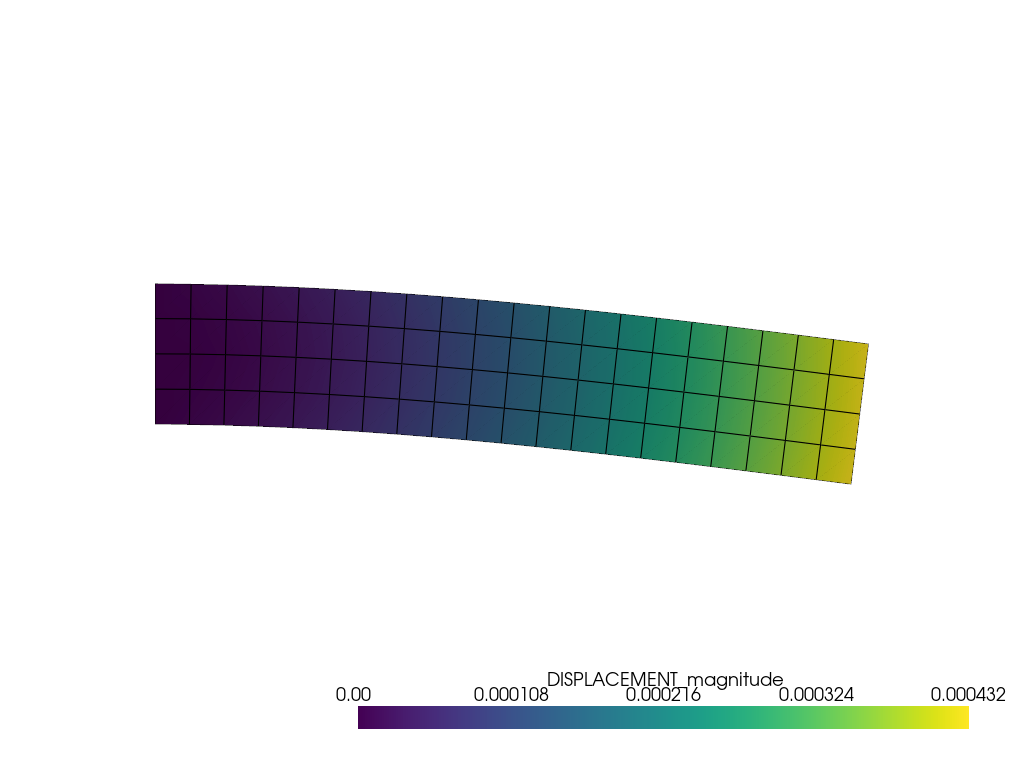

{
  "file": "/tmp/kratos-mcp-cantilever-41ut68ft/vtk_output/Structure_0_1.vtk",
  "variable": "DISPLACEMENT",
  "component": null,
  "camera": "xy",
  "warp_by": "DISPLACEMENT",
  "warp_factor": 200.0,
  "window_size": [
    1024,
    768
  ],
  "crop_bounds": null,
  "image_path": "/tmp/kratos-mcp-cantilever-41ut68ft/vtk_output/Structure_0_1_DISPLACEMENT.png",
  "data_range": [
    0.0,
    0.0004319658037275076
  ]
}


{'file': '/tmp/kratos-mcp-cantilever-41ut68ft/vtk_output/Structure_0_1.vtk',
 'variable': 'DISPLACEMENT',
 'component': None,
 'camera': 'xy',
 'warp_by': 'DISPLACEMENT',
 'warp_factor': 200.0,
 'window_size': [1024, 768],
 'crop_bounds': None,
 'image_path': '/tmp/kratos-mcp-cantilever-41ut68ft/vtk_output/Structure_0_1_DISPLACEMENT.png',
 'data_range': [0.0, 0.0004319658037275076]}

In [36]:
await call(
    "results_render",
    file=vtk_file, variable="DISPLACEMENT",
    warp_by="DISPLACEMENT", warp_factor=200, camera="xy",
)

## 9. Bonus: a dynamic run, live progress, an animated GIF, and cancelling a job

Switching to the `structural_dynamic` template turns this into an implicit Newmark time integration. We release the load after 0.05 s and watch the plate ring in free vibration — good material for `results_animate` and for polling `job_status` while a job is still `running` instead of waiting for it up front with `wait_seconds`.

In [37]:
dyn_dir = Path(tempfile.mkdtemp(prefix="kratos-mcp-cantilever-dynamic-"))

await call(
    "mdpa_create_structured_mesh",
    path=str(dyn_dir / "mesh.mdpa"), kind="rectangle",
    size=[1.0, 0.2], divisions=[16, 3],
)
await call(
    "create_project",
    directory=str(dyn_dir), template="structural_dynamic", name="cantilever_dyn",
    overrides={"end_time": 0.3, "time_step": 0.01},
)
await call(
    "add_boundary_condition",
    parameters_file=str(dyn_dir / "ProjectParameters.json"),
    kind="line_load", model_part="Structure.right",
    modulus=500_000.0, direction=[0.0, -1.0, 0.0], interval=[0.0, 0.05],
)
await call("validate_case", case_dir=str(dyn_dir))

{
  "written_to": "/tmp/kratos-mcp-cantilever-dynamic-q4ydi4i5/mesh.mdpa",
  "num_nodes": 68,
  "num_elements": 48,
  "num_conditions": 38,
  "elements_by_type": {
    "SmallDisplacementElement2D4N": 48
  },
  "conditions_by_type": {
    "LineLoadCondition2D2N": 38
  },
  "properties_ids": [
    1
  ],
  "bounding_box": {
    "min": [
      0.0,
      0.0,
      0.0
    ],
    "max": [
      1.0,
      0.20000000000000004,
      0.0
    ]
  },
  "sub_model_parts": {
    "domain": {
      "nodes": 68,
      "elements": 48,
      "conditions": 0,
      "sub_model_parts": {}
    },
    "left": {
      "nodes": 4,
      "elements": 0,
      "conditions": 3,
      "sub_model_parts": {}
    },
    "right": {
      "nodes": 4,
      "elements": 0,
      "conditions": 3,
      "sub_model_parts": {}
    },
    "bottom": {
      "nodes": 17,
      "elements": 0,
      "conditions": 16,
      "sub_model_parts": {}
    },
    "top": {
      "nodes": 17,
      "elements": 0,
      "conditions": 16,

{'valid': True, 'issues': [], 'warnings': []}

In [38]:
dyn_run = await call("run_simulation", case_dir=str(dyn_dir), wait_seconds=0)
dyn_job_id = dyn_run["job_id"]

# Poll instead of blocking: this is the pattern for longer-running jobs.
while True:
    status = await session.call_tool("job_status", {"job_id": dyn_job_id})
    status = json.loads(status.content[0].text)
    progress = status["progress"]
    print(f"{status['state']:10s} step={progress['current_step']} "
          f"time={progress['current_time']}")
    if status["state"] in ("succeeded", "failed", "cancelled"):
        break
    await asyncio.sleep(0.5)

{
  "job_id": "20260714-173955-bc58c7",
  "case_dir": "/tmp/kratos-mcp-cantilever-dynamic-q4ydi4i5",
  "parameters_file": "ProjectParameters.json",
  "state": "running",
  "pid": 2856961,
  "returncode": null,
  "created_at": 1784043595.3677783,
  "started_at": 1784043595.3677783,
  "finished_at": null,
  "analysis_type": null,
  "extra": {},
  "elapsed_seconds": 0.0
}
running    step=None time=None


succeeded  step=30 time=0.3000000000000001


In [39]:
await call("results_convergence", job_id=dyn_job_id)

{
  "num_steps": 30,
  "num_converged": 30,
  "num_not_converged": 0,
  "max_iterations_in_a_step": 0,
  "steps": [
    {
      "step": 1,
      "time": 0.01,
      "iterations": 0,
      "residual_ratios": [
        6.26991e-07
      ],
      "converged": true
    },
    {
      "step": 2,
      "time": 0.02,
      "iterations": 0,
      "residual_ratios": [
        6.7739e-07
      ],
      "converged": true
    },
    {
      "step": 3,
      "time": 0.03,
      "iterations": 0,
      "residual_ratios": [
        6.6268e-07
      ],
      "converged": true
    },
    {
      "step": 4,
      "time": 0.04,
      "iterations": 0,
      "residual_ratios": [
        7.71501e-07
      ],
      "converged": true
    },
    {
      "step": 5,
      "time": 0.05,
      "iterations": 0,
      "residual_ratios": [
        6.90796e-07
      ],
      "converged": true
    },
    {
      "step": 6,
      "time": 0.060000000000000005,
      "iterations": 0,
      "residual_ratios": [
        7.13

{'num_steps': 30,
 'num_converged': 30,
 'num_not_converged': 0,
 'max_iterations_in_a_step': 0,
 'steps': [{'step': 1,
   'time': 0.01,
   'iterations': 0,
   'residual_ratios': [6.26991e-07],
   'converged': True},
  {'step': 2,
   'time': 0.02,
   'iterations': 0,
   'residual_ratios': [6.7739e-07],
   'converged': True},
  {'step': 3,
   'time': 0.03,
   'iterations': 0,
   'residual_ratios': [6.6268e-07],
   'converged': True},
  {'step': 4,
   'time': 0.04,
   'iterations': 0,
   'residual_ratios': [7.71501e-07],
   'converged': True},
  {'step': 5,
   'time': 0.05,
   'iterations': 0,
   'residual_ratios': [6.90796e-07],
   'converged': True},
  {'step': 6,
   'time': 0.060000000000000005,
   'iterations': 0,
   'residual_ratios': [7.13247e-07],
   'converged': True},
  {'step': 7,
   'time': 0.07,
   'iterations': 0,
   'residual_ratios': [6.16893e-07],
   'converged': True},
  {'step': 8,
   'time': 0.08,
   'iterations': 0,
   'residual_ratios': [5.92031e-07],
   'converged':

In [40]:
await call("results_list", case_dir=str(dyn_dir))

{
  "case_dir": "/tmp/kratos-mcp-cantilever-dynamic-q4ydi4i5",
  "results": {
    "vtk": [
      "vtk_output/Structure_0_1.vtk",
      "vtk_output/Structure_0_10.vtk",
      "vtk_output/Structure_0_11.vtk",
      "vtk_output/Structure_0_12.vtk",
      "vtk_output/Structure_0_13.vtk",
      "vtk_output/Structure_0_14.vtk",
      "vtk_output/Structure_0_15.vtk",
      "vtk_output/Structure_0_16.vtk",
      "vtk_output/Structure_0_17.vtk",
      "vtk_output/Structure_0_18.vtk",
      "vtk_output/Structure_0_19.vtk",
      "vtk_output/Structure_0_2.vtk",
      "vtk_output/Structure_0_20.vtk",
      "vtk_output/Structure_0_21.vtk",
      "vtk_output/Structure_0_22.vtk",
      "vtk_output/Structure_0_23.vtk",
      "vtk_output/Structure_0_24.vtk",
      "vtk_output/Structure_0_25.vtk",
      "vtk_output/Structure_0_26.vtk",
      "vtk_output/Structure_0_27.vtk",
      "vtk_output/Structure_0_28.vtk",
      "vtk_output/Structure_0_29.vtk",
      "vtk_output/Structure_0_3.vtk",
      "vtk_outp

{'case_dir': '/tmp/kratos-mcp-cantilever-dynamic-q4ydi4i5',
 'results': {'vtk': ['vtk_output/Structure_0_1.vtk',
   'vtk_output/Structure_0_10.vtk',
   'vtk_output/Structure_0_11.vtk',
   'vtk_output/Structure_0_12.vtk',
   'vtk_output/Structure_0_13.vtk',
   'vtk_output/Structure_0_14.vtk',
   'vtk_output/Structure_0_15.vtk',
   'vtk_output/Structure_0_16.vtk',
   'vtk_output/Structure_0_17.vtk',
   'vtk_output/Structure_0_18.vtk',
   'vtk_output/Structure_0_19.vtk',
   'vtk_output/Structure_0_2.vtk',
   'vtk_output/Structure_0_20.vtk',
   'vtk_output/Structure_0_21.vtk',
   'vtk_output/Structure_0_22.vtk',
   'vtk_output/Structure_0_23.vtk',
   'vtk_output/Structure_0_24.vtk',
   'vtk_output/Structure_0_25.vtk',
   'vtk_output/Structure_0_26.vtk',
   'vtk_output/Structure_0_27.vtk',
   'vtk_output/Structure_0_28.vtk',
   'vtk_output/Structure_0_29.vtk',
   'vtk_output/Structure_0_3.vtk',
   'vtk_output/Structure_0_30.vtk',
   'vtk_output/Structure_0_4.vtk',
   'vtk_output/Structure_0

`results_animate` takes a directory or glob of result files, ordered by the timestep number in their names. To keep the GIF small for this notebook we hand it every other frame in a subdirectory instead of all 30 — same tool, just fewer input files.

In [41]:
import re

frames = sorted((dyn_dir / "vtk_output").glob("*.vtk"),
                key=lambda p: int(re.findall(r"\d+", p.stem)[-1]))
gif_frames_dir = dyn_dir / "vtk_output_gif"
gif_frames_dir.mkdir(exist_ok=True)
for f in frames[1::2]:
    shutil.copy(f, gif_frames_dir / f.name)
print(f"{len(frames)} frames simulated, {len(list(gif_frames_dir.iterdir()))} used for the GIF")

30 frames simulated, 15 used for the GIF


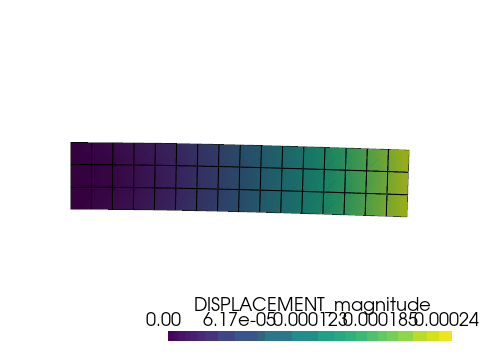

{
  "files": "/tmp/kratos-mcp-cantilever-dynamic-q4ydi4i5/vtk_output_gif",
  "variable": "DISPLACEMENT",
  "component": null,
  "camera": "xy",
  "warp_by": "DISPLACEMENT",
  "warp_factor": 100.0,
  "window_size": [
    480,
    360
  ],
  "crop_bounds": null,
  "gif_path": "/tmp/kratos-mcp-cantilever-dynamic-q4ydi4i5/vtk_output_gif/Structure_DISPLACEMENT.gif",
  "num_frames": 15,
  "fps": 5,
  "data_range": [
    0.0,
    0.0002468274615239352
  ]
}


{'files': '/tmp/kratos-mcp-cantilever-dynamic-q4ydi4i5/vtk_output_gif',
 'variable': 'DISPLACEMENT',
 'component': None,
 'camera': 'xy',
 'warp_by': 'DISPLACEMENT',
 'warp_factor': 100.0,
 'window_size': [480, 360],
 'crop_bounds': None,
 'gif_path': '/tmp/kratos-mcp-cantilever-dynamic-q4ydi4i5/vtk_output_gif/Structure_DISPLACEMENT.gif',
 'num_frames': 15,
 'fps': 5,
 'data_range': [0.0, 0.0002468274615239352]}

In [42]:
await call(
    "results_animate",
    files=str(gif_frames_dir), variable="DISPLACEMENT",
    warp_by="DISPLACEMENT", warp_factor=100, camera="xy",
    fps=5, window_size=[480, 360],
)

Finally, `job_cancel`: start a longer run and stop it mid-flight (SIGTERM, escalating to SIGKILL after a grace period).

In [43]:
cancel_dir = Path(tempfile.mkdtemp(prefix="kratos-mcp-cantilever-cancel-"))
await call(
    "mdpa_create_structured_mesh",
    path=str(cancel_dir / "mesh.mdpa"), kind="rectangle", size=[1.0, 0.2], divisions=[16, 3],
)
await call(
    "create_project",
    directory=str(cancel_dir), template="structural_dynamic", name="long_run",
    overrides={"end_time": 5.0, "time_step": 0.01},
)
await call(
    "add_boundary_condition",
    parameters_file=str(cancel_dir / "ProjectParameters.json"),
    kind="line_load", model_part="Structure.right",
    modulus=500_000.0, direction=[0.0, -1.0, 0.0],
)
long_run = await call("run_simulation", case_dir=str(cancel_dir), wait_seconds=0)
long_job_id = long_run["job_id"]

{
  "written_to": "/tmp/kratos-mcp-cantilever-cancel-3jpczf5k/mesh.mdpa",
  "num_nodes": 68,
  "num_elements": 48,
  "num_conditions": 38,
  "elements_by_type": {
    "SmallDisplacementElement2D4N": 48
  },
  "conditions_by_type": {
    "LineLoadCondition2D2N": 38
  },
  "properties_ids": [
    1
  ],
  "bounding_box": {
    "min": [
      0.0,
      0.0,
      0.0
    ],
    "max": [
      1.0,
      0.20000000000000004,
      0.0
    ]
  },
  "sub_model_parts": {
    "domain": {
      "nodes": 68,
      "elements": 48,
      "conditions": 0,
      "sub_model_parts": {}
    },
    "left": {
      "nodes": 4,
      "elements": 0,
      "conditions": 3,
      "sub_model_parts": {}
    },
    "right": {
      "nodes": 4,
      "elements": 0,
      "conditions": 3,
      "sub_model_parts": {}
    },
    "bottom": {
      "nodes": 17,
      "elements": 0,
      "conditions": 16,
      "sub_model_parts": {}
    },
    "top": {
      "nodes": 17,
      "elements": 0,
      "conditions": 16,


In [44]:
await asyncio.sleep(0.5)  # let it actually start before we cancel it
await call("job_cancel", job_id=long_job_id)

{
  "job_id": "20260714-173957-34615b",
  "case_dir": "/tmp/kratos-mcp-cantilever-cancel-3jpczf5k",
  "parameters_file": "ProjectParameters.json",
  "state": "cancelled",
  "pid": 2857139,
  "returncode": null,
  "created_at": 1784043597.0471463,
  "started_at": 1784043597.0471463,
  "finished_at": 1784043602.5620384,
  "analysis_type": null,
  "extra": {}
}


{'job_id': '20260714-173957-34615b',
 'case_dir': '/tmp/kratos-mcp-cantilever-cancel-3jpczf5k',
 'parameters_file': 'ProjectParameters.json',
 'state': 'cancelled',
 'pid': 2857139,
 'returncode': None,
 'created_at': 1784043597.0471463,
 'started_at': 1784043597.0471463,
 'finished_at': 1784043602.5620384,
 'analysis_type': None,
 'extra': {}}

In [45]:
await call("job_status", job_id=long_job_id)

{
  "job_id": "20260714-173957-34615b",
  "case_dir": "/tmp/kratos-mcp-cantilever-cancel-3jpczf5k",
  "parameters_file": "ProjectParameters.json",
  "state": "cancelled",
  "pid": 2857139,
  "returncode": null,
  "created_at": 1784043597.0471463,
  "started_at": 1784043597.0471463,
  "finished_at": 1784043602.5620384,
  "analysis_type": null,
  "extra": {},
  "elapsed_seconds": 5.5,
  "progress": {
    "current_step": 114,
    "current_time": 1.1400000000000008,
    "num_steps_seen": 114,
    "errors_detected": []
  }
}


{'job_id': '20260714-173957-34615b',
 'case_dir': '/tmp/kratos-mcp-cantilever-cancel-3jpczf5k',
 'parameters_file': 'ProjectParameters.json',
 'state': 'cancelled',
 'pid': 2857139,
 'returncode': None,
 'created_at': 1784043597.0471463,
 'started_at': 1784043597.0471463,
 'finished_at': 1784043602.5620384,
 'analysis_type': None,
 'extra': {},
 'elapsed_seconds': 5.5,
 'progress': {'current_step': 114,
  'current_time': 1.1400000000000008,
  'num_steps_seen': 114,
  'errors_detected': []}}

## 10. Bonus: scaffolding without `create_project`

`create_project` is a convenience wrapper around two lower-level tools — useful when you want to generate a `ProjectParameters.json` in isolation (e.g. to inspect it, or to write it somewhere `create_project`'s fixed layout doesn't fit) or hand-roll a `Materials.json` from scratch.

In [46]:
await call(
    "create_project_parameters",
    template="structural_static",
    overrides={"end_time": 2.0, "fix_model_part": "Structure.left"},
)

{
  "parameters": {
    "problem_data": {
      "problem_name": "case",
      "parallel_type": "OpenMP",
      "echo_level": 1,
      "start_time": 0.0,
      "end_time": 2.0
    },
    "solver_settings": {
      "solver_type": "Static",
      "model_part_name": "Structure",
      "domain_size": 2,
      "echo_level": 1,
      "analysis_type": "linear",
      "model_import_settings": {
        "input_type": "mdpa",
        "input_filename": "mesh"
      },
      "material_import_settings": {
        "materials_filename": "Materials.json"
      },
      "time_stepping": {
        "time_step": 1.1
      },
      "linear_solver_settings": {
        "solver_type": "LinearSolversApplication.sparse_lu"
      },
      "rotation_dofs": false
    },
    "processes": {
      "constraints_process_list": [
        {
          "python_module": "assign_vector_variable_process",
          "kratos_module": "KratosMultiphysics",
          "process_name": "AssignVectorVariableProcess",
          "Parame

{'parameters': {'problem_data': {'problem_name': 'case',
   'parallel_type': 'OpenMP',
   'echo_level': 1,
   'start_time': 0.0,
   'end_time': 2.0},
  'solver_settings': {'solver_type': 'Static',
   'model_part_name': 'Structure',
   'domain_size': 2,
   'echo_level': 1,
   'analysis_type': 'linear',
   'model_import_settings': {'input_type': 'mdpa', 'input_filename': 'mesh'},
   'material_import_settings': {'materials_filename': 'Materials.json'},
   'time_stepping': {'time_step': 1.1},
   'linear_solver_settings': {'solver_type': 'LinearSolversApplication.sparse_lu'},
   'rotation_dofs': False},
  'processes': {'constraints_process_list': [{'python_module': 'assign_vector_variable_process',
     'kratos_module': 'KratosMultiphysics',
     'process_name': 'AssignVectorVariableProcess',
     'Parameters': {'model_part_name': 'Structure.left',
      'variable_name': 'DISPLACEMENT',
      'interval': [0.0, 'End'],
      'constrained': [True, True, True],
      'value': [0.0, 0.0, 0.0]}}

In [47]:
await call(
    "create_materials",
    output_file=str(workdir / "Materials_manual.json"),
    materials=[{
        "model_part_name": "Structure.domain",
        "constitutive_law": "LinearElasticPlaneStrain2DLaw",
        "variables": {"YOUNG_MODULUS": 210e9, "POISSON_RATIO": 0.3, "DENSITY": 7850.0},
    }],
)

{
  "written_to": "/tmp/kratos-mcp-cantilever-41ut68ft/Materials_manual.json",
  "materials": {
    "properties": [
      {
        "model_part_name": "Structure.domain",
        "properties_id": 1,
        "Material": {
          "Variables": {
            "YOUNG_MODULUS": 210000000000.0,
            "POISSON_RATIO": 0.3,
            "DENSITY": 7850.0
          },
          "Tables": {},
          "constitutive_law": {
            "name": "LinearElasticPlaneStrain2DLaw"
          }
        }
      }
    ]
  }
}


{'written_to': '/tmp/kratos-mcp-cantilever-41ut68ft/Materials_manual.json',
 'materials': {'properties': [{'model_part_name': 'Structure.domain',
    'properties_id': 1,
    'Material': {'Variables': {'YOUNG_MODULUS': 210000000000.0,
      'POISSON_RATIO': 0.3,
      'DENSITY': 7850.0},
     'Tables': {},
     'constitutive_law': {'name': 'LinearElasticPlaneStrain2DLaw'}}}]}}

## New capabilities: process schemas, presets, explain & Flowgraph interop

These tools were added after this walkthrough was first written. `kratos_get_process_defaults` recovers a process' parameters by parsing Kratos source; `list_material_presets` offers ready-made materials; `explain_project_parameters` summarises any case; and the Flowgraph tools convert a case to/from the visual node editor, losslessly.

In [48]:
await call("kratos_get_process_defaults", python_module="assign_scalar_variable_process")

{
  "python_module": "assign_scalar_variable_process",
  "default_settings": {
    "help": "This process sets a given scalar value for a certain variable in all the nodes of a submodelpart",
    "model_part_name": "please_specify_model_part_name",
    "variable_name": "SPECIFY_VARIABLE_NAME",
    "interval": [
      0.0,
      1e+30
    ],
    "constrained": true,
    "value": {},
    "local_axes": {}
  },
  "param_types": {
    "help": "string",
    "model_part_name": "string",
    "variable_name": "string",
    "interval": "array",
    "constrained": "bool",
    "value": "json",
    "local_axes": "json"
  },
  "input_model_parts": [
    "model_part_name"
  ],
  "output_params": {
    "variable_name": "SPECIFY_VARIABLE_NAME",
    "interval": [
      0.0,
      1e+30
    ],
    "constrained": true,
    "value": {},
    "local_axes": {}
  },
  "help": "This process sets a given scalar value for a certain variable in all the nodes of a submodelpart"
}


{'python_module': 'assign_scalar_variable_process',
 'default_settings': {'help': 'This process sets a given scalar value for a certain variable in all the nodes of a submodelpart',
  'model_part_name': 'please_specify_model_part_name',
  'variable_name': 'SPECIFY_VARIABLE_NAME',
  'interval': [0.0, 1e+30],
  'constrained': True,
  'value': {},
  'local_axes': {}},
 'param_types': {'help': 'string',
  'model_part_name': 'string',
  'variable_name': 'string',
  'interval': 'array',
  'constrained': 'bool',
  'value': 'json',
  'local_axes': 'json'},
 'input_model_parts': ['model_part_name'],
 'output_params': {'variable_name': 'SPECIFY_VARIABLE_NAME',
  'interval': [0.0, 1e+30],
  'constrained': True,
  'value': {},
  'local_axes': {}},
 'help': 'This process sets a given scalar value for a certain variable in all the nodes of a submodelpart'}

In [49]:
await call("list_material_presets")

{
  "linear_elastic_3d": {
    "description": "Linear elastic isotropic solid (3D). Small-strain Hooke's law.",
    "application": "StructuralMechanicsApplication",
    "constitutive_law": "LinearElastic3DLaw",
    "variables": {
      "YOUNG_MODULUS": 210000000000.0,
      "POISSON_RATIO": 0.3,
      "DENSITY": 7850.0
    }
  },
  "linear_elastic_plane_strain": {
    "description": "Linear elastic isotropic solid, 2D plane-strain assumption.",
    "application": "StructuralMechanicsApplication",
    "constitutive_law": "LinearElasticPlaneStrain2DLaw",
    "variables": {
      "YOUNG_MODULUS": 210000000000.0,
      "POISSON_RATIO": 0.3,
      "DENSITY": 7850.0
    }
  },
  "linear_elastic_plane_stress": {
    "description": "Linear elastic isotropic solid, 2D plane-stress assumption (thin sheets).",
    "application": "StructuralMechanicsApplication",
    "constitutive_law": "LinearElasticPlaneStress2DLaw",
    "variables": {
      "YOUNG_MODULUS": 210000000000.0,
      "POISSON_RATIO"

{'linear_elastic_3d': {'description': "Linear elastic isotropic solid (3D). Small-strain Hooke's law.",
  'application': 'StructuralMechanicsApplication',
  'constitutive_law': 'LinearElastic3DLaw',
  'variables': {'YOUNG_MODULUS': 210000000000.0,
   'POISSON_RATIO': 0.3,
   'DENSITY': 7850.0}},
 'linear_elastic_plane_strain': {'description': 'Linear elastic isotropic solid, 2D plane-strain assumption.',
  'application': 'StructuralMechanicsApplication',
  'constitutive_law': 'LinearElasticPlaneStrain2DLaw',
  'variables': {'YOUNG_MODULUS': 210000000000.0,
   'POISSON_RATIO': 0.3,
   'DENSITY': 7850.0}},
 'linear_elastic_plane_stress': {'description': 'Linear elastic isotropic solid, 2D plane-stress assumption (thin sheets).',
  'application': 'StructuralMechanicsApplication',
  'constitutive_law': 'LinearElasticPlaneStress2DLaw',
  'variables': {'YOUNG_MODULUS': 210000000000.0,
   'POISSON_RATIO': 0.3,
   'DENSITY': 7850.0}},
 'small_strain_plasticity_von_mises_3d': {'description': 'S

In [50]:
await call("explain_project_parameters", parameters_file=str(workdir / "ProjectParameters.json"))

{
  "kind": "single_stage",
  "analysis_type": "structural",
  "analysis_stage": "KratosMultiphysics.StructuralMechanicsApplication.structural_mechanics_analysis",
  "problem_name": "cantilever",
  "parallel_type": "OpenMP",
  "start_time": 0.0,
  "end_time": 1.0,
  "solver": {
    "solver_type": "Static",
    "model_part_name": "Structure",
    "domain_size": 2
  },
  "linear_solver": {
    "solver_type": "LinearSolversApplication.sparse_lu"
  },
  "model_import": {
    "input_type": "mdpa",
    "input_filename": "mesh"
  },
  "materials": {
    "materials_filename": "Materials.json"
  },
  "processes": [
    {
      "list": "constraints_process_list",
      "python_module": "assign_vector_variable_process",
      "kratos_module": "KratosMultiphysics",
      "process_name": "AssignVectorVariableProcess",
      "model_parts": [
        "Structure.left"
      ]
    },
    {
      "list": "loads_process_list",
      "python_module": "assign_vector_by_direction_to_condition_process",
    

{'kind': 'single_stage',
 'analysis_type': 'structural',
 'analysis_stage': 'KratosMultiphysics.StructuralMechanicsApplication.structural_mechanics_analysis',
 'problem_name': 'cantilever',
 'parallel_type': 'OpenMP',
 'start_time': 0.0,
 'end_time': 1.0,
 'solver': {'solver_type': 'Static',
  'model_part_name': 'Structure',
  'domain_size': 2},
 'linear_solver': {'solver_type': 'LinearSolversApplication.sparse_lu'},
 'model_import': {'input_type': 'mdpa', 'input_filename': 'mesh'},
 'materials': {'materials_filename': 'Materials.json'},
 'processes': [{'list': 'constraints_process_list',
   'python_module': 'assign_vector_variable_process',
   'kratos_module': 'KratosMultiphysics',
   'process_name': 'AssignVectorVariableProcess',
   'model_parts': ['Structure.left']},
  {'list': 'loads_process_list',
   'python_module': 'assign_vector_by_direction_to_condition_process',
   'kratos_module': 'KratosMultiphysics',
   'process_name': 'AssignVectorByDirectionToConditionProcess',
   'model

In [51]:
await call("export_case_to_flowgraph",
           parameters_file=str(workdir / "ProjectParameters.json"),
           output_file=str(workdir / "graph.json"))
back = await call("import_flowgraph_to_case",
                  graph_file=str(workdir / "graph.json"))
original = json.loads((workdir / "ProjectParameters.json").read_text())
print("Flowgraph round-trip reproduces the original exactly:",
      json.dumps(original, sort_keys=True) == json.dumps(back["parameters"], sort_keys=True))

{
  "graph": {
    "last_node_id": 9,
    "last_link_id": 8,
    "nodes": [
      {
        "id": 1,
        "type": "Solvers/Structural mechanics/StructuralMechanicsSolver",
        "pos": [
          260,
          100
        ],
        "size": [
          220,
          100
        ],
        "flags": {},
        "mode": 0,
        "inputs": [],
        "outputs": [],
        "properties": {
          "_role": "solver_settings",
          "_analysis_stage": "KratosMultiphysics.StructuralMechanicsApplication.structural_mechanics_analysis",
          "_process_lists": [
            "constraints_process_list",
            "loads_process_list",
            "list_other_processes"
          ],
          "_output_process_lists": [
            "gid_output",
            "vtk_output"
          ],
          "_fragment": {
            "solver_type": "Static",
            "model_part_name": "Structure",
            "domain_size": 2,
            "echo_level": 1,
            "analysis_type": "lin

## Cleanup

Close the client session (which stops the server subprocess). The case
directories are left on disk — `workdir`, `dyn_dir` and `cancel_dir` printed
above — open their `vtk_output/` in ParaView if you want to look at the raw
results yourself.

In [52]:
_stop_event.set()      # wake the lifecycle task up ...
await _server_task     # ... and let it exit its own AsyncExitStack from the task that opened it
print("session closed, server subprocess terminated")
for d in (workdir, dyn_dir, cancel_dir):
    print(d)

session closed, server subprocess terminated
/tmp/kratos-mcp-cantilever-41ut68ft
/tmp/kratos-mcp-cantilever-dynamic-q4ydi4i5
/tmp/kratos-mcp-cantilever-cancel-3jpczf5k
